Encoding in python

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, MinMaxScaler


In [3]:
iris = load_iris()
print(iris.DESCR)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

In [7]:
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = pd.Series(iris.target, name="target")

df = pd.concat([X, y], axis=1)

print(df.iloc[[25, 75, 125]])

     sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
25                 5.0               3.0                1.6               0.2   
75                 6.6               3.0                4.4               1.4   
125                7.2               3.2                6.0               1.8   

     target  
25        0  
75        1  
125       2  


1. Normalizzazione

In [8]:
scaler_nomr = MinMaxScaler()
X_norm = pd.DataFrame(scaler_nomr.fit_transform(X), columns=X.columns)

print (X_norm.iloc[[25, 75, 125]].T)


                        25        75        125
sepal length (cm)  0.194444  0.638889  0.805556
sepal width (cm)   0.416667  0.416667  0.500000
petal length (cm)  0.101695  0.576271  0.847458
petal width (cm)   0.041667  0.541667  0.708333


2. Standardizzazione

In [9]:
scaler_std = StandardScaler()
X_std = pd.DataFrame(scaler_std.fit_transform(X), columns=X.columns)

print(X_std.iloc[[25, 75, 125]].T)



                        25        75        125
sepal length (cm) -1.021849  0.916837  1.643844
sepal width (cm)  -0.131979 -0.131979  0.328414
petal length (cm) -1.226552  0.364896  1.274295
petal width (cm)  -1.315444  0.264142  0.790671


3. Confronto grafico con BoxPlot

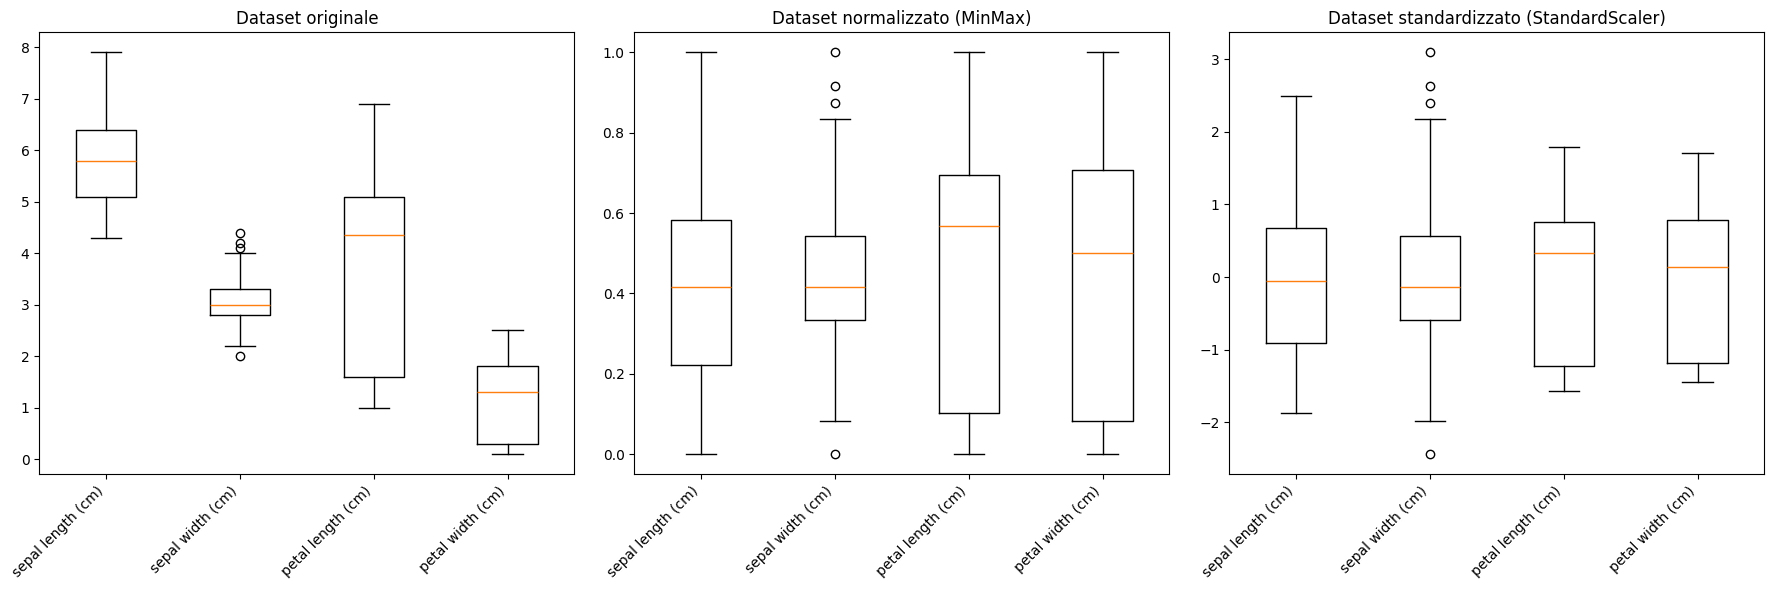

In [10]:
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.boxplot(X.values)
plt.title("Dataset originale")
plt.xticks(ticks=range(1, len(X.columns) + 1), labels=X.columns, rotation=45, ha= "right")

plt.subplot(1, 3, 2)
plt.boxplot(X_norm.values)
plt.title("Dataset normalizzato (MinMax)")
plt.xticks(ticks=range(1, len(X.columns) + 1), labels=X_norm.columns, rotation=45, ha= "right")

plt.subplot(1, 3, 3)
plt.boxplot(X_std.values)
plt.title("Dataset standardizzato (StandardScaler)")
plt.xticks(ticks=range(1, len(X.columns) + 1), labels=X_std.columns, rotation=45, ha= "right")


plt.tight_layout()
plt.show()


Training di modelli diversi con i tipi di scaling

In [11]:
datasets = [X, X_norm, X_std]

kmeans, knmeans_norm, kmeans_std = [KMeans(n_clusters=3, random_state=42).fit(dataset) for dataset in datasets]

models = [kmeans, knmeans_norm, kmeans_std]


Le labels individuate dai cluster sono 0, 1 e 2 e non si possono confrontare direttamente con le y. Per questo motivo è necessario andare a rimappare ogni cluster alla classe più rappresentata al suo interno attraverso la seguente funzione di cluster accuracy, che:
- rietichetta i cluster in base alla classe prevalente
- calcola l'accuracy come rapporti del numero di campioni corretti su numero di campioni totali

In [12]:
def cluster_accuracy(y, labels):
    labels_pred = np.zeros_like(labels)
    for cluster in np.unique(labels):
        mask = labels == cluster
        most_common = np.bincount(y[mask]).argmax()
        labels_pred[mask] = most_common
    return np.mean(labels_pred == y)


In [13]:
titles =["Originale", "Normalizzato (MinMax)", "Standardizzato (StandardScaler)"]

for title, model in zip(titles, models):
    acc = cluster_accuracy(y, model.labels_)
    print(f"Accuratezza del clustering con dataset {title}: {acc:.3f}")

Accuratezza del clustering con dataset Originale: 0.887
Accuratezza del clustering con dataset Normalizzato (MinMax): 0.880
Accuratezza del clustering con dataset Standardizzato (StandardScaler): 0.667


Plot Kmeans Clustering

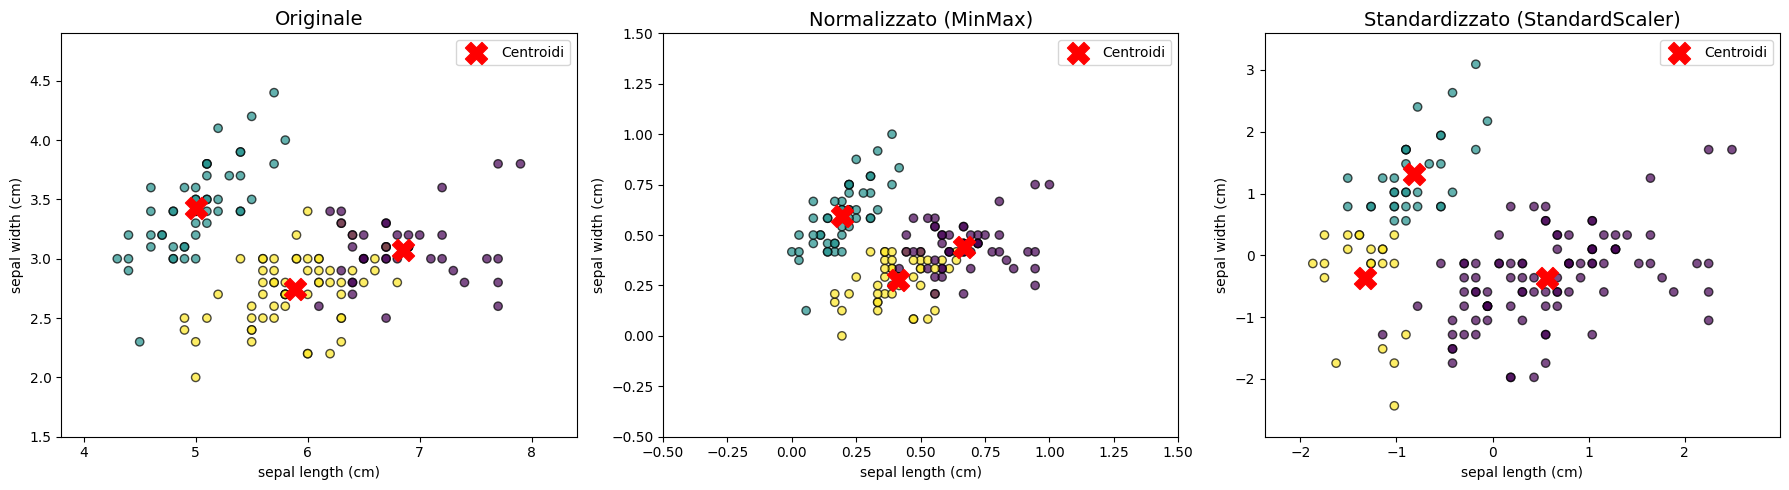

In [14]:
plt.figure(figsize=(18, 5))

for i, (m, d, t) in enumerate(zip(models, datasets, titles)):
    plt.subplot(1, 3, i + 1)
    plt.scatter(d.iloc[:, 0], d.iloc[:, 1], c=m.labels_, cmap="viridis", edgecolor="k", alpha=0.7)
    plt.scatter(m.cluster_centers_[:, 0], m.cluster_centers_[:, 1], c="red", marker="X", s=250, label="Centroidi")
    plt.xlim(d.iloc[:, 0].min() - 0.5, d.iloc[:, 0].max() + 0.5)
    plt.ylim(d.iloc[:, 1].min() - 0.5, d.iloc[:, 1].max() + 0.5)
    plt.title(t, fontsize=14)
    plt.xlabel(X.columns[0])
    plt.ylabel(X.columns[1])
    plt.legend()

plt.tight_layout()
plt.show()
